# Praktikum Pengantar Pembelajaran Mesin


---
## Bab 7. Metode Evaluasi Klasifikasi

Nama:


NIM:


Kelas:


## Membuat Fungsi-Fungsi Evaluasi yang Dibutuhkan

In [1]:
y_true = [0, 1, 2, 1, 2, 0, 1, 0, 2, 2] # Nilai sebenarnya
y_pred = [0, 1, 1, 1, 2, 0, 2, 0, 2, 1] # Prediksi
labels = [0, 1, 2] # Label kelas

In [2]:
import numpy as np

def confusion_matrix_multiclass(y_true, y_pred, labels):
  num_classes = len(labels)
  confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

  for true, pred in zip(y_true, y_pred):
    confusion_matrix[true][pred] += 1

  return confusion_matrix

def calculate_metrics(confusion_matrix):
  num_classes = confusion_matrix.shape[0]
  metrics = {}

  for i in range(num_classes):
    TP = confusion_matrix[i][i]
    FP = sum(confusion_matrix[:, i]) - TP
    FN = sum(confusion_matrix[i, :]) - TP
    TN = sum(confusion_matrix) - (TP + FP + FN)

    metrics[labels[i]] = {
      'TP': TP,
      'FP': FP,
      'FN': FN,
      'TN': TN
    }

  return metrics

confusion_matrix = confusion_matrix_multiclass(y_true, y_pred, labels)
metrics = calculate_metrics(confusion_matrix)

for label, metric in metrics.items():
    print(f"Class {label} - TP: {metric['TP']}, FP: {metric['FP']}, FN: {metric['FN']}, TN: {metric['TN']}")

Class 0 - TP: 3, FP: 0, FN: 0, TN: [0 1 0]
Class 1 - TP: 2, FP: 2, FN: 1, TN: [-2 -1 -2]
Class 2 - TP: 2, FP: 1, FN: 2, TN: [-2 -1 -2]


In [3]:
def hitung_precision_recall_f1_accuracy(y_true, y_pred, labels):
    cm = confusion_matrix_multiclass(y_true, y_pred, labels)
    metrics = calculate_metrics(cm)
    
    hasil = []
    for label, metric in metrics.items():
        precision = metric['TP'] / (metric['TP'] + metric['FP'])
        recall = metric['TP'] / (metric['TP'] + metric['FN'])
        f1_score = 2 * (precision * recall) / (precision + recall)
        accuracy_score = (metric['TP'] + metric['TN']) / (metric['TP'] + metric['FP'] + metric['FN'] + metric['TN'])
        
        hasil.append((f"Class {label} - Precision: {precision}, recall: {recall}, F1-Score: {f1_score}, accuracy: {accuracy_score}"))
    
    return hasil

display(hitung_precision_recall_f1_accuracy(y_true, y_pred, labels))

['Class 0 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: [1. 1. 1.]',
 'Class 1 - Precision: 0.5, recall: 0.6666666666666666, F1-Score: 0.5714285714285715, accuracy: [0.   0.25 0.  ]',
 'Class 2 - Precision: 0.6666666666666666, recall: 0.5, F1-Score: 0.5714285714285715, accuracy: [0.   0.25 0.  ]']

In [4]:
# Contoh data untuk roc-auc
y_true2 = [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
y_pred2 = [0.1, 0.4, 0.35, 0.8, 0.7, 0.55, 0.65, 0.9, 0.3, 0.6]

In [5]:
def calculate_tpr_fpr(y_true, y_pred, threshold):
  tp = 0
  fp = 0
  fn = 0
  tn = 0

  for i in range(len(y_true)):
    if y_pred[i] >= threshold:
      if y_true[i] == 1:
        tp += 1
      else:
        fp += 1

    else:
      if y_true[i] == 1:
        fn += 1
      else:
        tn += 1

  tpr = tp / (tp + fn)
  fpr = fp / (fp + tn)

  return tpr, fpr

In [6]:
def calculate_roc_auc(y_true, y_pred):
  thresholds = sorted(set(y_pred), reverse=True)
  roc_points = []

  for threshold in thresholds:
    tpr, fpr = calculate_tpr_fpr(y_true, y_pred, threshold)
    roc_points.append((fpr, tpr))

  # Menghitung AUC menggunakan metode trapezoid
  auc = 0.0
  for i in range(1, len(roc_points)):
    x1, y1 = roc_points[i - 1]
    x2, y2 = roc_points[i]
    auc += (x2 - x1) * (y1 + y2) / 2.0

  return roc_points, auc

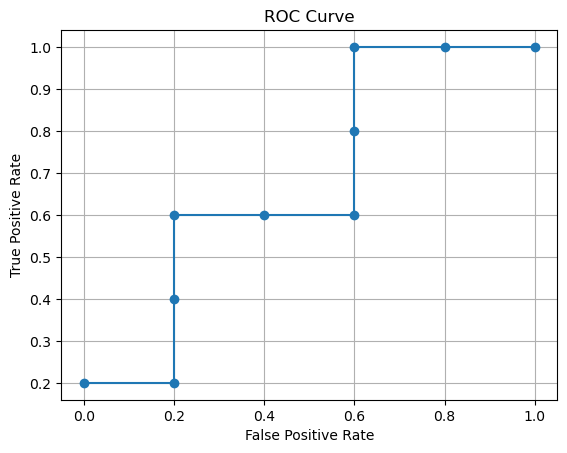

In [7]:
import matplotlib.pyplot as plt

def tampilkan_roc_curve(y_true, y_pred):
  roc_points, auc = calculate_roc_auc(y_true, y_pred)

  x, y = zip(*roc_points)
  plt.plot(x, y, marker='o')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')

  plt.grid(True)

  plt.show()

tampilkan_roc_curve(y_true2, y_pred2)

## 7.5. Tugas

1. Buatkan _method_ untuk menghitung F1-Score dan akurasi rata-rata!

In [8]:
def hitung_f1_score(y_true, y_pred, labels):
    hasil = hitung_precision_recall_f1_accuracy(y_true, y_pred, labels)
    f1_scores = [hasil[label]['f1_score'] for label in labels]
    # Mengatasi NaN apabila terjadi pembagian dengan nol
    f1_scores = [f1 if not np.isnan(f1) else 0.0 for f1 in f1_scores]
    return sum(f1_scores) / len(labels)

def hitung_accuracy_rata(y_true, y_pred, labels):
    hasil = hitung_precision_recall_f1_accuracy(y_true, y_pred, labels)
    accuracies = [hasil[label]['accuracy'] for label in labels]
    return sum(accuracies) / len(labels)

2. Buat kode program untuk menghitung MCC dari percobaan subbab 7.4!

In [9]:
import math

def hitung_mcc(y_true, y_pred, labels):
    cm = confusion_matrix_multiclass(y_true, y_pred, labels)
    c = np.trace(cm)
    s = np.sum(cm)
    p = np.sum(cm, axis=0)
    t = np.sum(cm, axis=1)
    
    numerator = c * s - np.dot(p, t)
    denom = math.sqrt((s**2 - np.dot(p, p)) * (s**2 - np.dot(t, t)))
    
    if denom == 0:
        return 0.0
    return numerator / denom

3. Gunakan semua matriks evaluasi yang ada di bab ini untuk menghitung kinerja SVM pada _dataset_ iris yang sudah dipraktikkan pada bab sebelumnya!

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# Load data iris
df_iris = pd.read_csv('data/iris_dataset.csv')
X = df_iris.drop(columns=['target'])
y = df_iris['target']

# Encode label string ke numerik
le = LabelEncoder()
y_encoded = le.fit_transform(y)
labels_iris = list(range(len(le.classes_)))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Train SVM Model
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Prediksi untuk label (multiclass) dan probabilitas (untuk ROC-AUC, jika diperlukan adaptasi ke multiclass/OVR)
# Catatan: Fungsi calculate_roc_auc yang ada sebelumnya hanya mendukung probabilitas 1D (binary). 
# Kita akan gunakan prediksi kelas sebagai pendekatan sederhana untuk fungsionalitas yang ada, atau salah satu probabilitas.
y_pred_iris = svm_model.predict(X_test)
y_prob_iris = svm_model.predict_proba(X_test)[:, 1] # Ambil probabilitas kelas 1 untuk ROC-AUC sebagai contoh

Evaluasi dengan confusion matrix: 
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
==================== Pemisah ====================
Evaluasi dengan beberapa skor untuk setiap kelasnya:


['Class 0 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: [1. 1. 1.]',
 'Class 1 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: [1. 1. 1.]',
 'Class 2 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: [1. 1. 1.]']

==================== Pemisah ====================
Evaluasi dengan nilai dari ROC: [(0.0, 0.1111111111111111), (0.0, 0.2222222222222222), (0.0, 0.3333333333333333), (0.0, 0.4444444444444444), (0.0, 0.5555555555555556), (0.0, 0.6666666666666666), (0.0, 0.7777777777777778), (0.0, 0.8888888888888888), (0.0, 1.0), (0.047619047619047616, 1.0), (0.09523809523809523, 1.0), (0.14285714285714285, 1.0), (0.19047619047619047, 1.0), (0.23809523809523808, 1.0), (0.2857142857142857, 1.0), (0.3333333333333333, 1.0), (0.38095238095238093, 1.0), (0.42857142857142855, 1.0), (0.47619047619047616, 1.0), (0.5238095238095238, 1.0), (0.5714285714285714, 1.0), (0.6190476190476191, 1.0), (0.6666666666666666, 1.0), (0.7142857142857143, 1.0), (0.7619047619047619, 1.0), (0.8095238095238095, 1.0), (0.8571428571428571, 1.0), (0.9047619047619048, 1.0), (0.9523809523809523, 1.0), (1.0, 1.0)]
AUC: 1.0



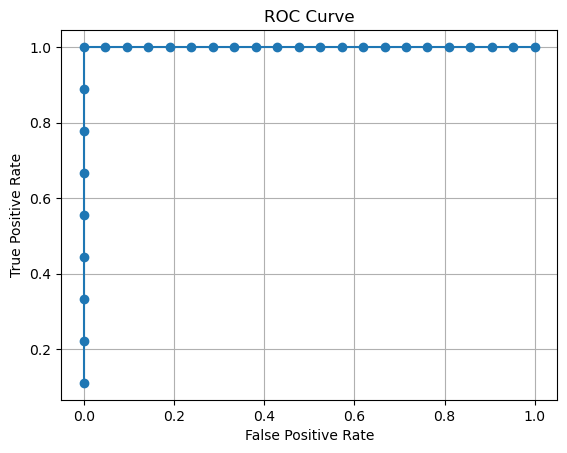

==================== Pemisah ====================
Evaluasi dengan skor MCC:
1.0


In [12]:
# Evaluasi dengan metode Confusion Matrix
print('Evaluasi dengan confusion matrix: ')
print(confusion_matrix_multiclass(y_test, y_pred_iris, labels_iris)) 

print('==================== Pemisah ====================')

# Evaluasi dengan metode Precision, Recall, F1, dan Accuracy
print('Evaluasi dengan beberapa skor untuk setiap kelasnya:')
display(hitung_precision_recall_f1_accuracy(y_test, y_pred_iris, labels_iris)) 

print('==================== Pemisah ====================')

# Note: perhitungan nilai ROC-AUC yang dibuat pada modul didesain berdasarkan format probabilitas kelas positif untuk klasifikasi biner.
# Sebagai demonstrasi, kita gunakan salah satu probabilitas agar bisa kompatibel dengan calculate_roc_auc buatan sendiri.
roc_points, auc = calculate_roc_auc(y_test == 1, y_prob_iris) 
print(f'Evaluasi dengan nilai dari ROC: {roc_points}\nAUC: {auc}\n')
tampilkan_roc_curve(y_test == 1, y_prob_iris) 

print('==================== Pemisah ====================')

# Evaluasi dengan menghitung MCC
print(f'Evaluasi dengan skor MCC:')
print(hitung_mcc(y_test, y_pred_iris, labels_iris))

## 7.6. Kesimpulan

Kesimpulan apa yang kamu dapatkan selama praktikum Modul 7 ini, menjawab dari pertanyaan-pertanyaan di bawah ini:
1. Apakah tujuan percobaan telah tercapai?
2. Apa hubungan antara hasil percobaan dan dasar teori?
3. Faktor-faktor apa saja yang memengaruhi hasil percobaan, termasuk kemungkinan kesalahan yang terjadi?

Isi dengan kesimpulan ...